In [2]:
""" External Imports """
import maboss
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import sys
import yaml
import numpy as np
import re
import seaborn as sns
from datetime import datetime
from matplotlib.patches import Patch
import matplotlib.lines as mlines
from matplotlib.patches import Rectangle

sys.path.append("/Users/emilieyu/endotehelial-masboss")

ipylab module is not installed, menus and toolbar are disabled.


In [3]:
from boolean_models.analysis.plot_params import *

In [4]:
""" Global Setting Configuration """

from src.config import load_sim_config, load_sweep_config
from src.paths import *
from boolean_models.scripts import *

sim_cfg = load_sim_config()
sweep_cfg = load_sweep_config()

MODELS_BND = DATA_DIR / sim_cfg['model']['bnd_v2']
MODELS_CFG = DATA_DIR / sim_cfg['model']['cfg_v4']


In [5]:
perb_csv = BM_RESULTS_DIR / 'perturbation_timeseries.csv'
perb_raw = pd.read_csv(perb_csv)
param_csv = BM_RESULTS_DIR / 'param_sweep_full.csv'
param_df = pd.read_csv(param_csv)
param_df

,DSP,JCAD,RhoA,RhoC,TJP1,p1_name,p1_value,p2_name,p2_value,perturbation,exp_name,type,delta,phenotype
0,0.500801,0.499799,0.338022,0.641812,0.504799,$RhoA_amp,0.0,NaN,NaN,WT,WT_Sweep,1D,0.303790,Hyper
1,0.505999,0.522800,0.496760,0.566100,0.491801,$RhoA_amp,2.5,NaN,NaN,WT,WT_Sweep,1D,0.069340,Normal
2,0.493401,0.506000,0.537039,0.553523,0.499000,$RhoA_amp,5.0,NaN,NaN,WT,WT_Sweep,1D,0.016484,Normal
3,0.504202,0.489402,0.545275,0.549506,0.489800,$RhoA_amp,7.5,NaN,NaN,WT,WT_Sweep,1D,0.004231,Normal
4,0.511399,0.508000,0.566590,0.552572,0.502000,$RhoA_amp,10.0,NaN,NaN,WT,WT_Sweep,1D,-0.014018,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1611,0.491800,0.477599,0.550701,0.626167,0.498198,$RhoA_basal,0.8,$RhoC_basal,1.2,WT,Basal_Activity_Robustness,2D,0.075466,Normal
1612,0.502999,0.501799,0.725361,0.369284,0.503000,$RhoA_basal,1.2,$RhoC_basal,0.0,WT,Basal_Activity_Robustness,2D,-0.356077,Failed
1613,0.492600,0.499799,0.663786,0.494201,0.517601,$RhoA_basal,1.2,$RhoC_basal,0.4,WT,Basal_Activity_Robustness,2D,-0.169585,Normal
1614,0.497598,0.503599,0.632080,0.557995,0.497798,$RhoA_basal,1.2,$RhoC_basal,0.8,WT,Basal_Activity_Robustness,2D,-0.074085,Normal


## 1D Experiements Processing

In [6]:
df_1d = param_df[param_df['type'] == "1D"].dropna(axis=1).copy()
groups_1d = {"RhoA Deactivation": ["$RhoA_decay", "$RhoA_antagonistic"],
             "RhoC Deactivation": ["$RhoC_decay", "$RhoC_antagonistic"],
             "RhoA Junction Activation": ["$RhoA_mod", "$RhoA_amp"],
             "RhoC Junction Activatio": ["$RhoC_mod", "$RhoC_amp"], 
             "Basal Robustness": ["$RhoA_basal", "$RhoC_basal"]}

df_1d

,RhoA,RhoC,p1_name,p1_value,perturbation,exp_name,type,delta,phenotype
0,0.338022,0.641812,$RhoA_amp,0.0,WT,WT_Sweep,1D,0.303790,Hyper
1,0.496760,0.566100,$RhoA_amp,2.5,WT,WT_Sweep,1D,0.069340,Normal
2,0.537039,0.553523,$RhoA_amp,5.0,WT,WT_Sweep,1D,0.016484,Normal
3,0.545275,0.549506,$RhoA_amp,7.5,WT,WT_Sweep,1D,0.004231,Normal
4,0.566590,0.552572,$RhoA_amp,10.0,WT,WT_Sweep,1D,-0.014018,Normal
...,...,...,...,...,...,...,...,...,...
423,0.557371,0.415027,$RhoC_basal,0.6,TJP1_JCAD_DKO,TJP1_JCAD_Sweep,1D,-0.142344,Normal
424,0.518977,0.492399,$RhoC_basal,0.8,TJP1_JCAD_DKO,TJP1_JCAD_Sweep,1D,-0.026578,Normal
425,0.494485,0.559300,$RhoC_basal,1.0,TJP1_JCAD_DKO,TJP1_JCAD_Sweep,1D,0.064815,Normal
426,0.473930,0.586645,$RhoC_basal,1.2,TJP1_JCAD_DKO,TJP1_JCAD_Sweep,1D,0.112715,Normal


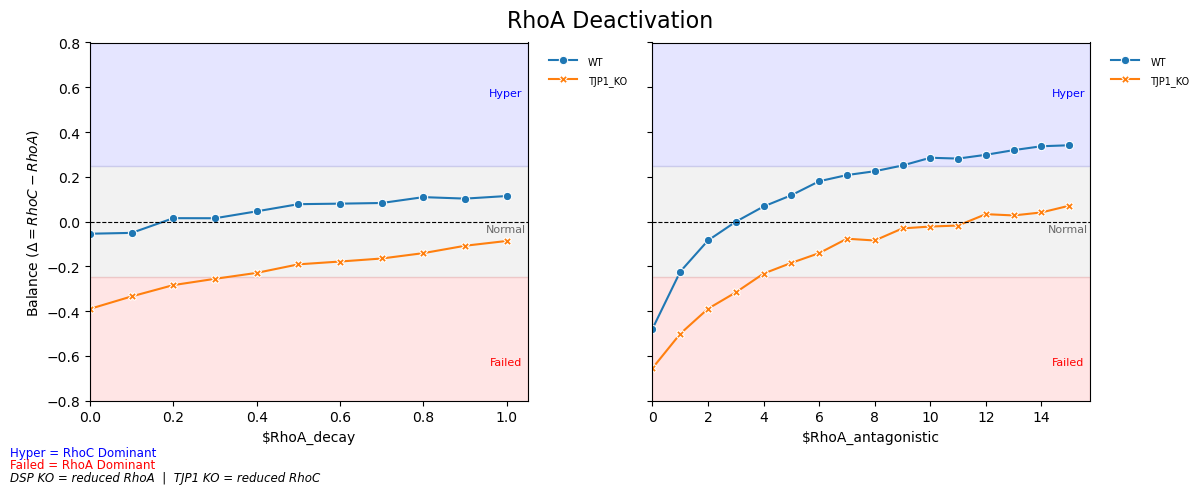

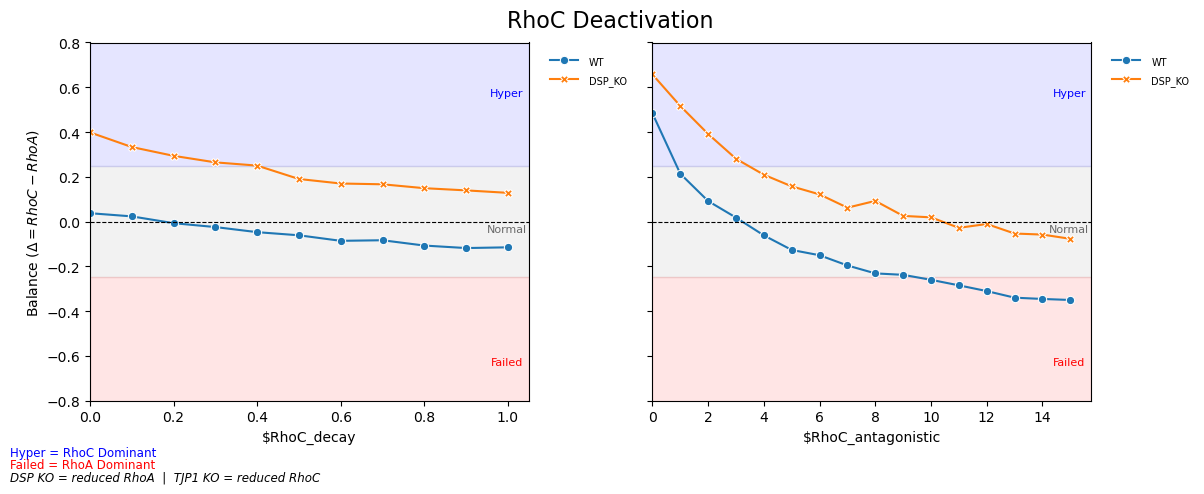

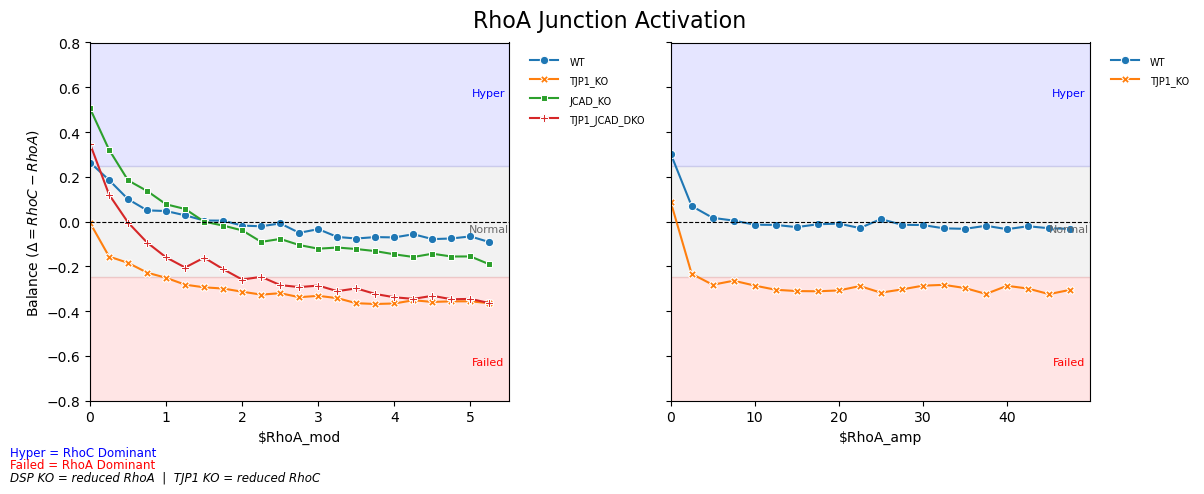

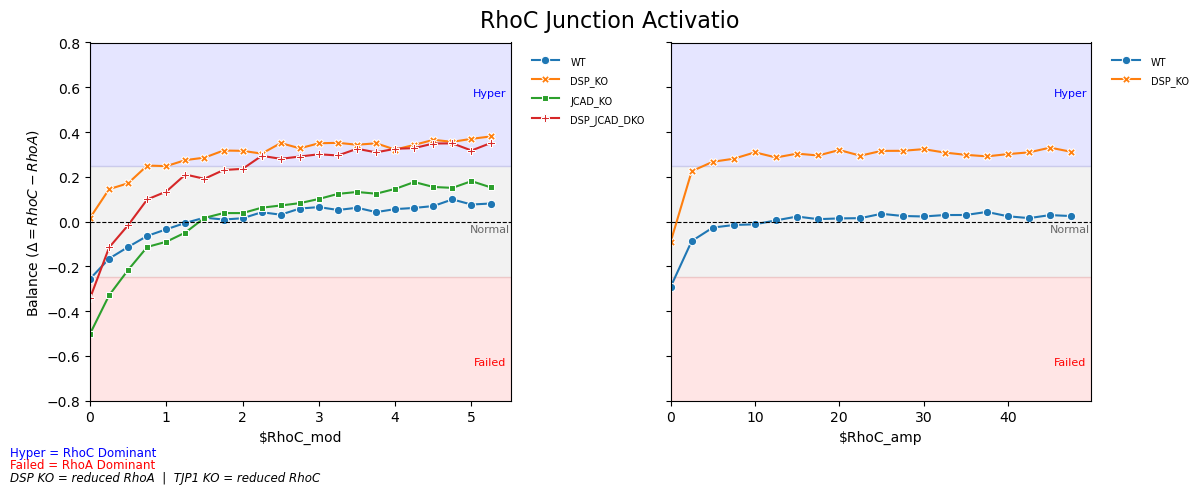

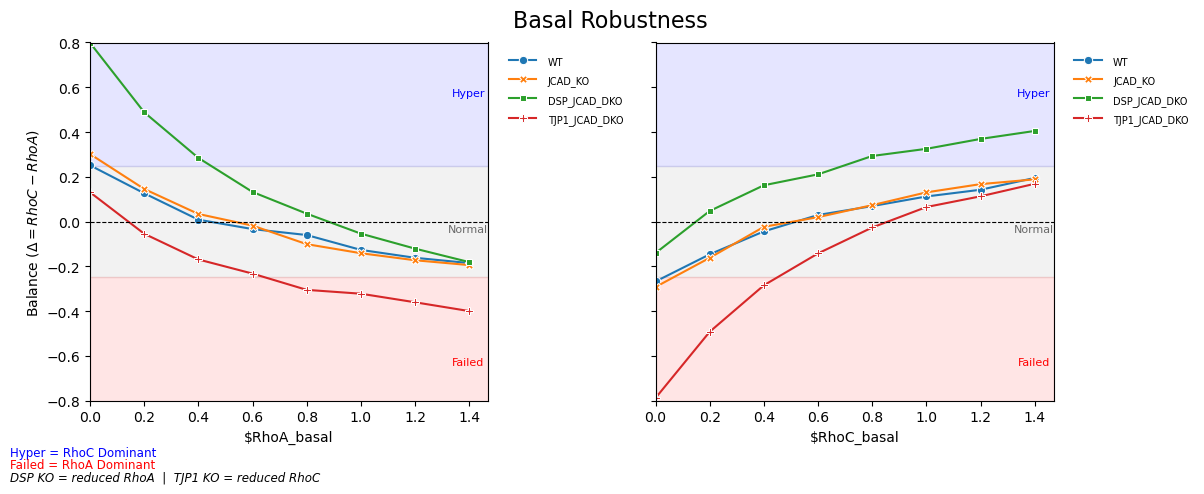

In [11]:

for title, group in groups_1d.items(): 
    plot_1d(df_1d, metric='delta', title=title, eps=0.25, group=group, outdir=PARAM_FIG_DIR, )

## 2D Param Sweep Processing

In [8]:
df_2d = param_df[param_df['type'] == "2D"].dropna(axis=1).copy()
df_2d.round(2)

,RhoA,RhoC,p1_name,p1_value,p2_name,p2_value,perturbation,exp_name,type,delta,phenotype
428,1.00,1.00,$RhoA_antagonistic,0.0,$RhoC_antagonistic,0.0,WT,Competition_Landscape,2D,0.00,Normal
429,0.89,0.43,$RhoA_antagonistic,0.0,$RhoC_antagonistic,2.0,WT,Competition_Landscape,2D,-0.45,Failed
430,0.87,0.34,$RhoA_antagonistic,0.0,$RhoC_antagonistic,4.0,WT,Competition_Landscape,2D,-0.53,Failed
431,0.86,0.30,$RhoA_antagonistic,0.0,$RhoC_antagonistic,6.0,WT,Competition_Landscape,2D,-0.56,Failed
432,0.85,0.28,$RhoA_antagonistic,0.0,$RhoC_antagonistic,8.0,WT,Competition_Landscape,2D,-0.57,Failed
...,...,...,...,...,...,...,...,...,...,...,...
1611,0.55,0.63,$RhoA_basal,0.8,$RhoC_basal,1.2,WT,Basal_Activity_Robustness,2D,0.08,Normal
1612,0.73,0.37,$RhoA_basal,1.2,$RhoC_basal,0.0,WT,Basal_Activity_Robustness,2D,-0.36,Failed
1613,0.66,0.49,$RhoA_basal,1.2,$RhoC_basal,0.4,WT,Basal_Activity_Robustness,2D,-0.17,Normal
1614,0.63,0.56,$RhoA_basal,1.2,$RhoC_basal,0.8,WT,Basal_Activity_Robustness,2D,-0.07,Normal


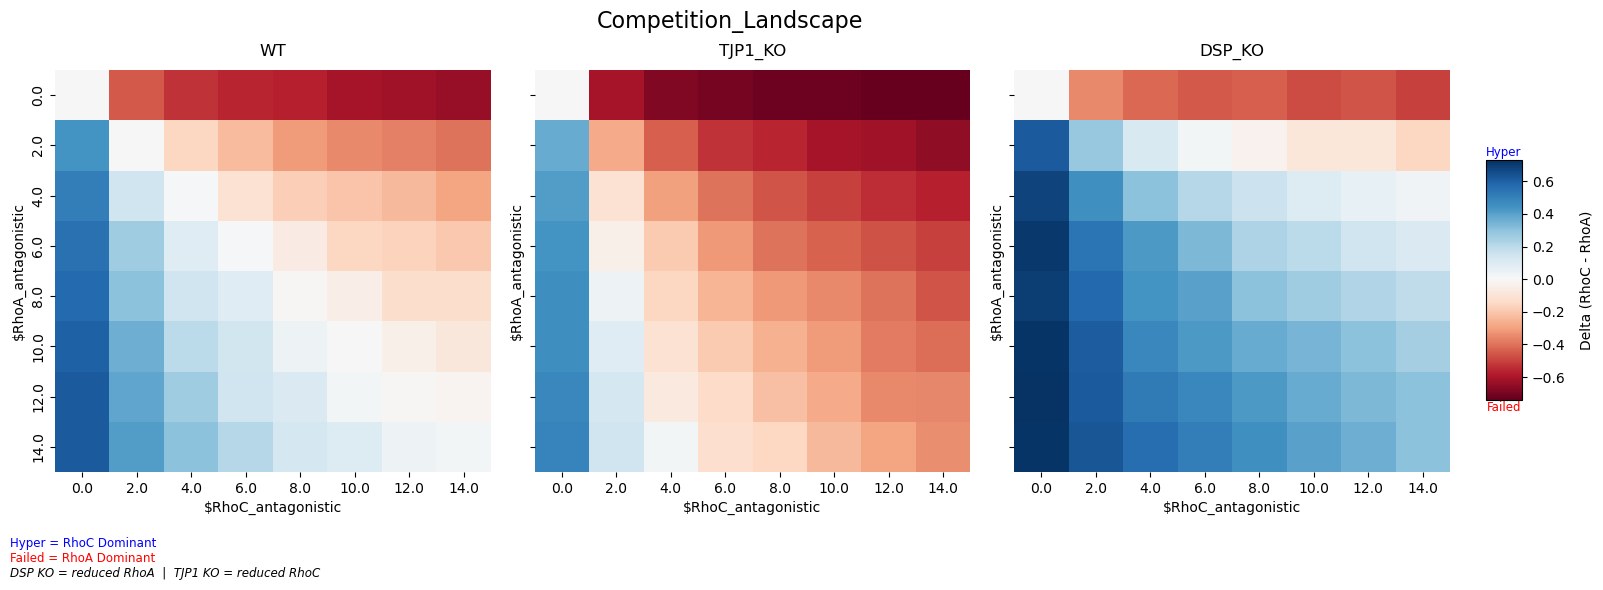

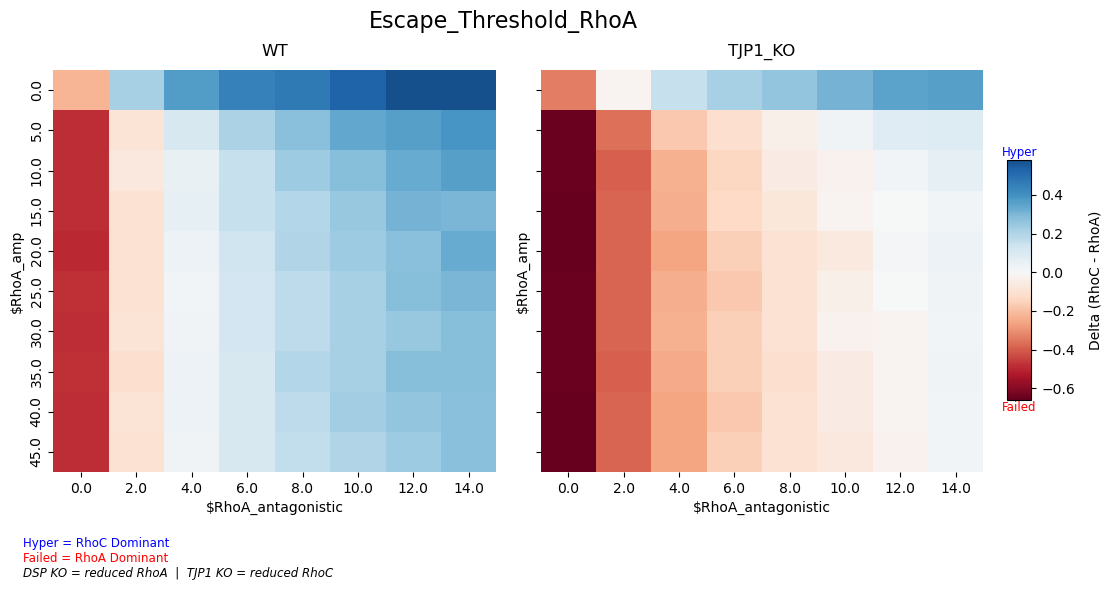

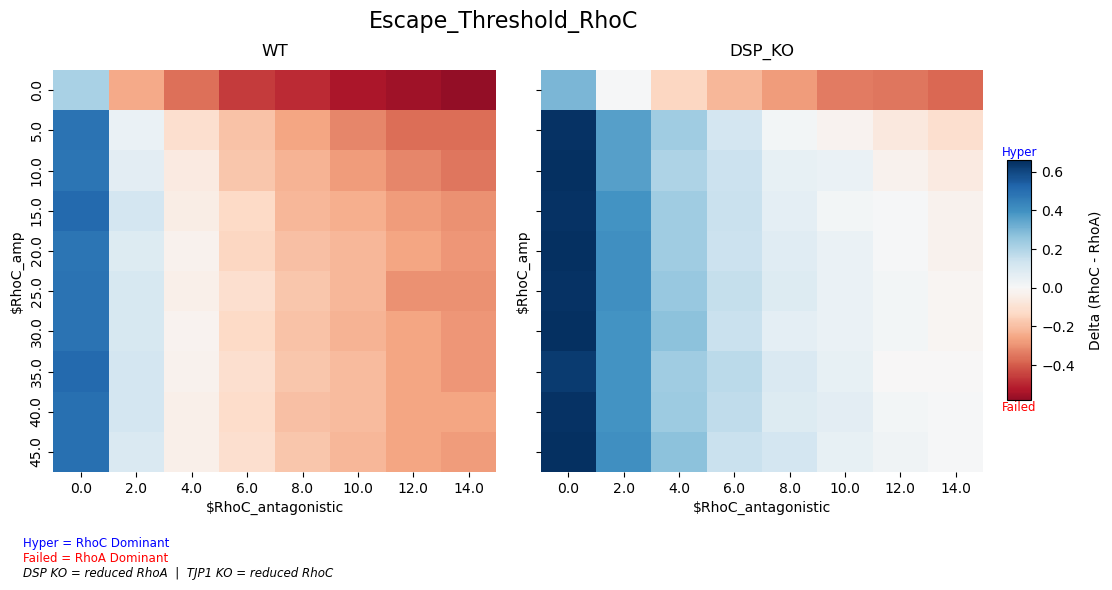

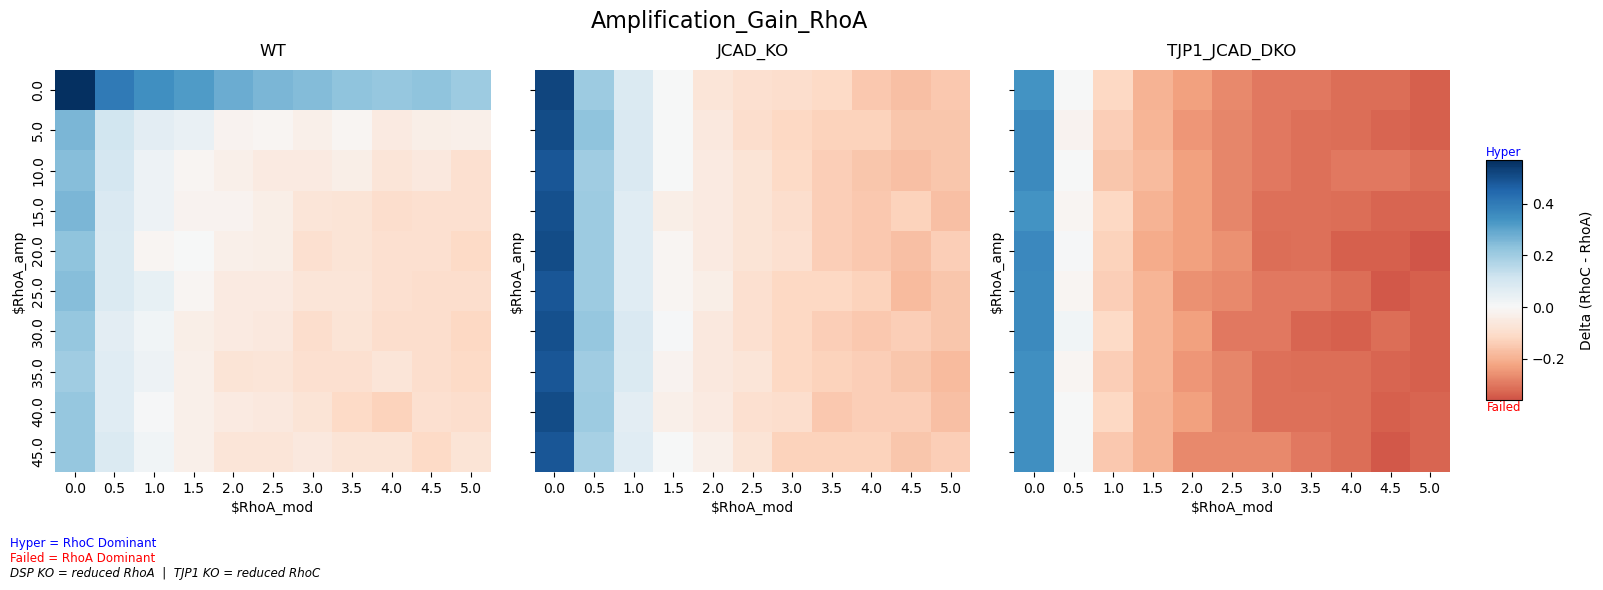

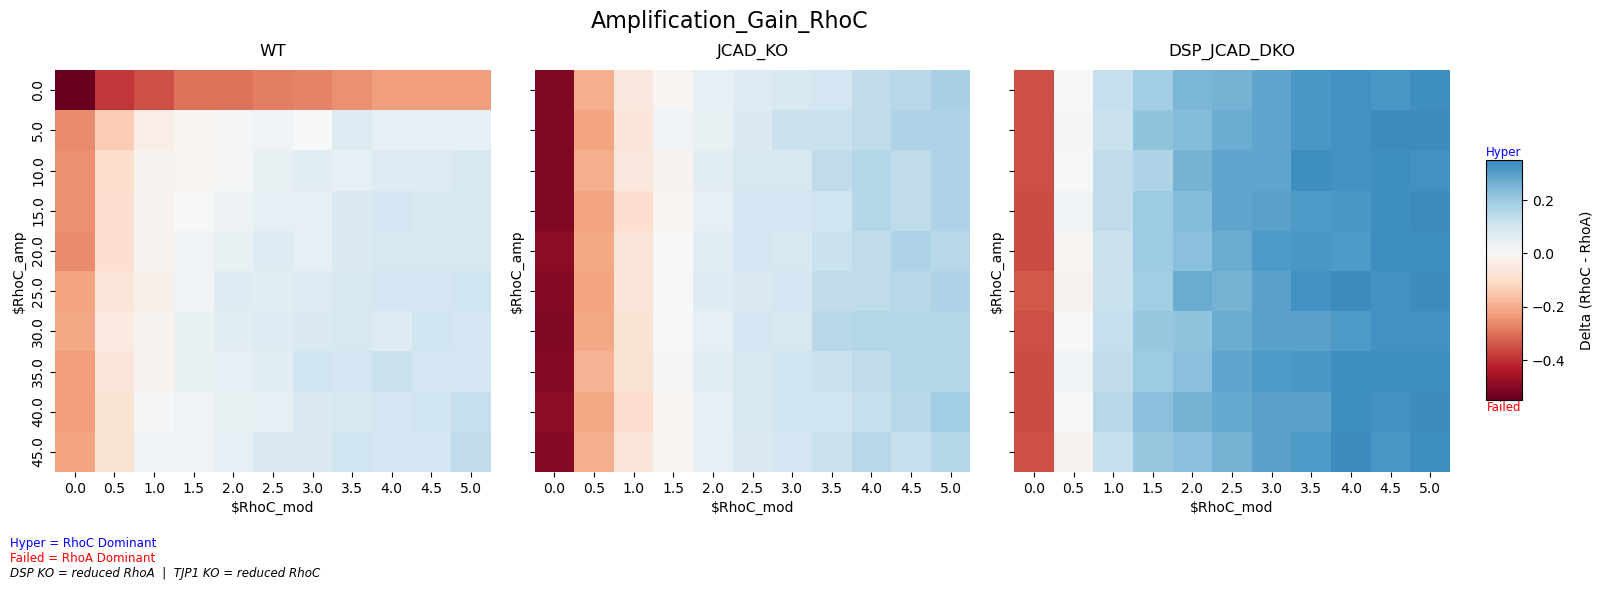

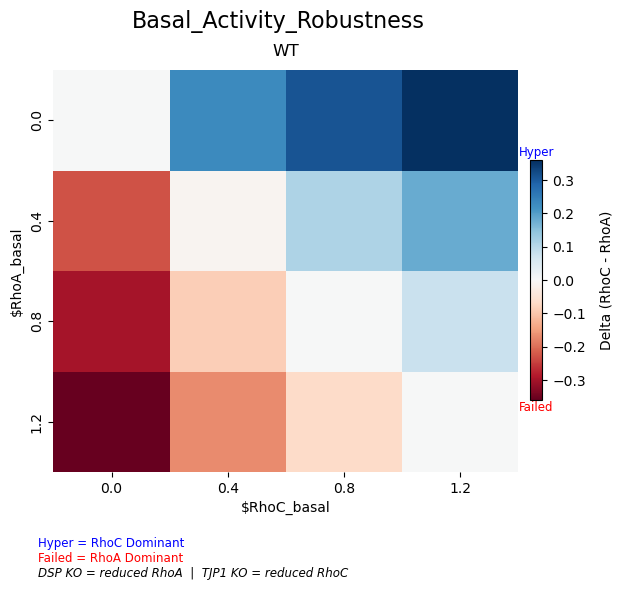

In [9]:

for exp in df_2d['exp_name'].unique():
    exp_df = df_2d[df_2d['exp_name'] == exp].round(2)
    plot_experiment_heatmaps(exp_df, PARAM_FIG_DIR)

## Perturbation Processing

In [13]:
def plot_activation_single(perb, df, ax, set_ylim=True):
    """
    Plot RhoA/RhoC activation levels / probabilities for a single perturbation. 
    """
    ax.plot(df['t'], df['RhoA'], label=f"{perb} RhoA")
    ax.plot(df['t'], df['RhoC'], label=f"{perb} RhoC")

    if set_ylim:
        ax.set_ylim(0, 1)

    ax.set_xlabel('Time')
    ax.set_ylabel('Activation Level (Probability)')

    plt.tight_layout()


def plot_activation_prob(name, perb_list, data_dict, outdir=None, set_ylim=True, save=True):
    fig, ax = plt.subplots(figsize=(6,4))

    for perb in perb_list:
        plot_activation_single(perb, data_dict[perb], ax=ax, set_ylim=set_ylim)

    ax.set_title(f"{name}: RhoA/RhoC Activation Over Time")
    ax.legend()
    plt.tight_layout()

    if save and outdir is not None:
        file_name = name.replace(" ", "_")
        fig.savefig(outdir / f"{file_name}_rho_acivation_time.png", dpi=300)

    plt.show()
    plt.close(fig)

def plot_delta_single(perb, df, ax):
    """
    Plot Δ(t) for a single perturbation onto an existing axis.
    """

    ax.plot(df['t'], df["delta"], label=perb)

    ax.set_ylim(-0.7, 0.7)
    ax.set_xlabel("Time")
    ax.set_ylabel("Δ = P(RhoC) − P(RhoA)")


def plot_deltas(name, perb_list, data_dict, outdir=None, save=True):
    """
    Plot one or multiple perturbations' Δ(t) on the same axes.
    """
    fig, ax = plt.subplots(figsize=(6,4))

    # Plot each perturbation
    for perb in perb_list:
        plot_delta_single(perb, data_dict[perb], ax)

    # Add reference lines ONCE
    ax.axhline(0.25, linestyle="--", color='mistyrose')
    ax.axhline(-0.25, linestyle="--", color='mistyrose')
    ax.axhline(0, linestyle=":", color='grey')

    ax.set_title(f"{name}: Rho Balance Over Time (Δ)")
    ax.legend(title='Perturbation')
    plt.tight_layout()

    if save and outdir is not None:
        file_name = name.replace(" ", "_")
        outpath = outdir / f"{file_name}_delta_time.png"
        fig.savefig(outpath, dpi=300)

    plt.show()

    plt.close()


In [14]:
perb_dfs = {}
for perb, df in perb_raw.groupby('perturbation'):
    perb_dfs[perb] = df

    #plot_activation_prob(perb, [perb], perb_dfs, PERBS_FIG_DIR)
    #plot_deltas(perb, df)


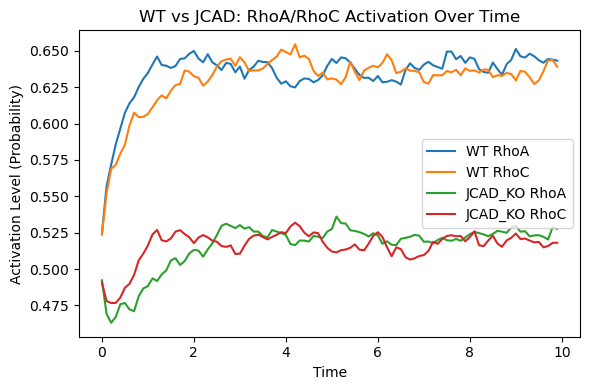

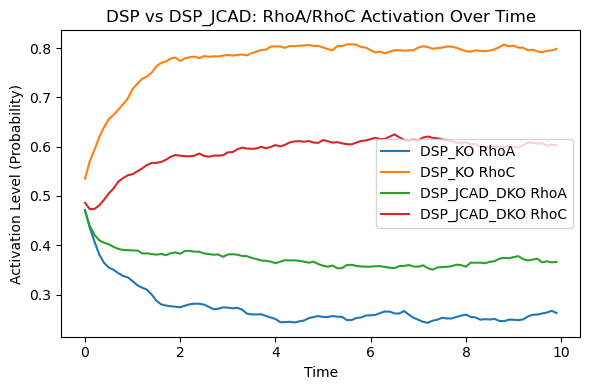

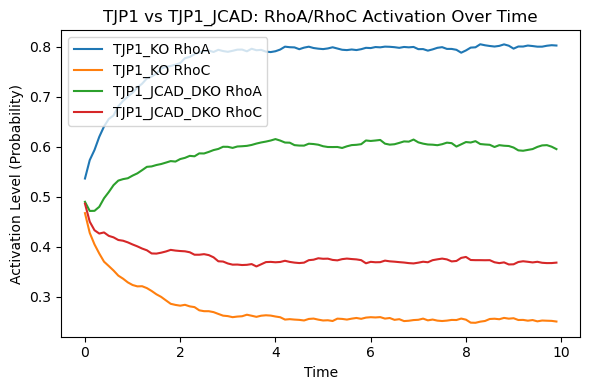

In [15]:
plot_activation_prob('WT vs JCAD', ['WT', 'JCAD_KO'], perb_dfs, PERB_FIG_DIR, set_ylim=False)
plot_activation_prob('DSP vs DSP_JCAD', ['DSP_KO', 'DSP_JCAD_DKO'], perb_dfs, PERB_FIG_DIR, set_ylim=False)
plot_activation_prob('TJP1 vs TJP1_JCAD', ['TJP1_KO', 'TJP1_JCAD_DKO'], perb_dfs, PERB_FIG_DIR, set_ylim=False)

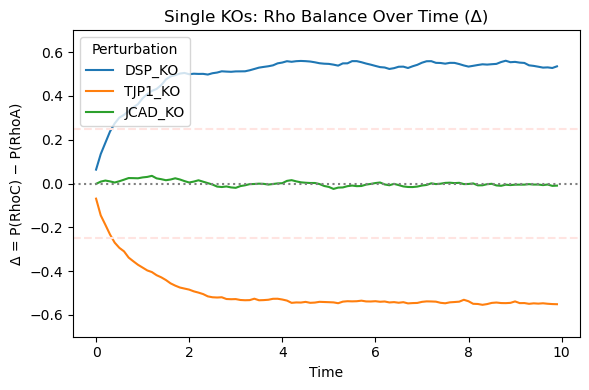

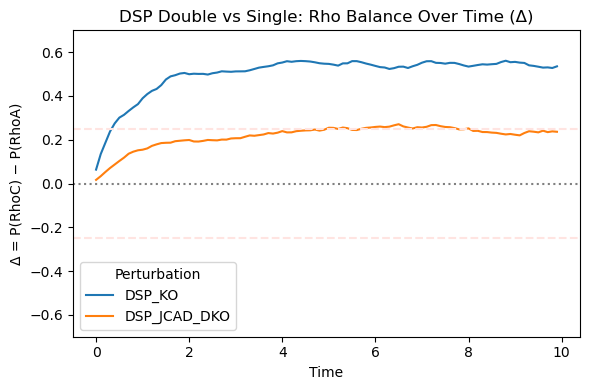

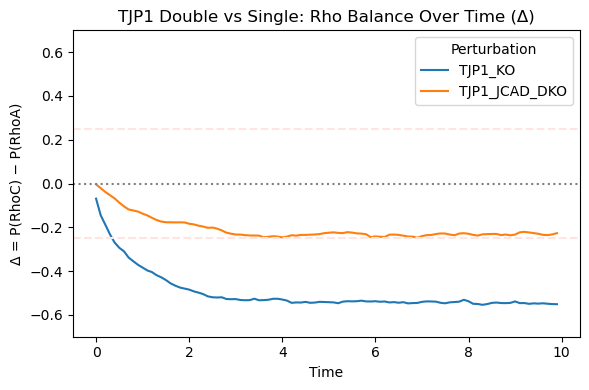

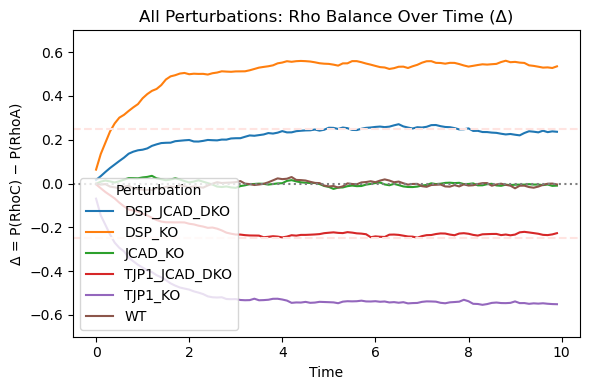

In [16]:
plot_deltas('Single KOs', ['DSP_KO', 'TJP1_KO', 'JCAD_KO'], perb_dfs, PERB_FIG_DIR)
plot_deltas('DSP Double vs Single', ['DSP_KO', 'DSP_JCAD_DKO'], perb_dfs, PERB_FIG_DIR)
plot_deltas('TJP1 Double vs Single', ['TJP1_KO', 'TJP1_JCAD_DKO'], perb_dfs, PERB_FIG_DIR)
plot_deltas('All Perturbations', perb_dfs.keys(), perb_dfs, PERB_FIG_DIR)

## Perturbation Steady State Plots

In [17]:
def plot_ss_bar(df, outdir=None, save=True):
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(df['perturbation'], df['delta'])

    ax.axhline(0.25, linestyle="--", color='red')
    ax.axhline(-0.25, linestyle="--", color='red')
    ax.axhline(0, linestyle=":", color='grey')

    ax.set_ylabel("Steady-State Δ")
    ax.set_ylabel("Perturbation")
    ax.set_title("Steady-State Rho Balances")

    plt.tight_layout()
    plt.show()

    if save and outdir is not None:
        outpath = outdir / "ss_balance_bar.png"
        fig.savefig(outpath, dpi=300)

    plt.show()

    plt.close(fig)


def save_df_as_png(df, filename, outdir = None, save=True, dpi=300):
    """
    Save a pandas DataFrame as a PNG image.
    """

    # Scale figure size based on dataframe shape
    nrows, ncols = df.shape

    fig, ax = plt.subplots(figsize=(ncols * 1.2, nrows * 0.4))
    ax.axis('off')

    table = ax.table(
        cellText=df.values,
        cellLoc='left',
        colLabels=df.columns.str.capitalize(),
        colColours=['lightblue']*ncols,
        loc='center'
    )


    table.auto_set_column_width(col=list(range(ncols)))
    table.scale(1, 1.2)

    # Bold header row
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')

    plt.tight_layout()
    if save and outdir is not None:
        outpath = outdir / "ss_table.png"
        fig.savefig(outpath, dpi=300)

    plt.show()
    plt.close(fig)

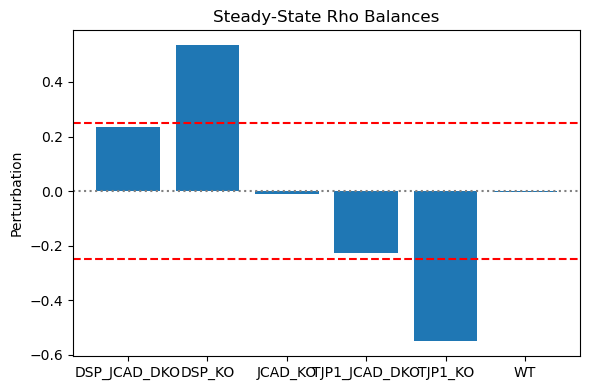

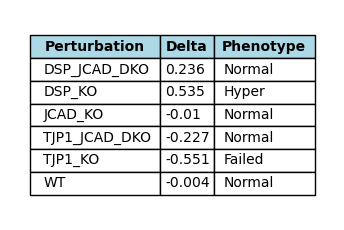

In [19]:
ss_df = perb_raw.loc[perb_raw.groupby('perturbation')['t'].idxmax()].reset_index(drop=True)
ss_df
ss_processed = ss_df[['perturbation', 'delta', 'phenotype']].round(3)
plot_ss_bar(ss_processed, PERB_FIG_DIR)
save_df_as_png(ss_processed, "ss_table", PERB_FIG_DIR)